# 10. Exploratory Data Analysis (EDA)

This notebook performs Phase-1 EDA on the merged financial time-series dataset to understand data quality, feature behavior, ticker coverage, volatility structure, and cross-market influence before feature engineering.

## 1. Imports and Setup

We import core analysis and visualization libraries, set plotting style, and configure display options for readable diagnostics.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 80)

RANDOM_SEED = 42

## 2. Load Dataset

Load the merged parquet dataset, standardize the date type, and sort observations by `Ticker` and `Date` for time-series consistency.

In [2]:
def resolve_data_path() -> Path:
    candidates = [
        Path("..") / "Market_Data" / "processed" / "merged_dataset.parquet",
        Path("Market_Data") / "processed" / "merged_dataset.parquet",
        Path("ml_pipeline") / "Market_Data" / "processed" / "merged_dataset.parquet",
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError("merged_dataset.parquet not found in expected locations.")


data_path = resolve_data_path()
df = pd.read_parquet(data_path)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print(f"Loaded file: {data_path}")
print(f"Shape: {df.shape}")

Loaded file: C:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\processed\merged_dataset.parquet
Shape: (65895, 41)


## 3. Dataset Overview

This section summarizes dataset size, market coverage, date span, and feature group composition.

In [3]:
dataset_shape = df.shape
unique_tickers = df["Ticker"].nunique()
date_min, date_max = df["Date"].min(), df["Date"].max()
trading_days = df["Date"].nunique()

print(f"Rows, Columns: {dataset_shape}")
print(f"Unique tickers: {unique_tickers}")
print(f"Date range: {date_min.date()} to {date_max.date()}")
print(f"Number of trading days: {trading_days}")

def available(cols):
    return [c for c in cols if c in df.columns]

column_groups = {
    "ID columns": available(["Date", "Ticker"]),
    "Price columns": available(["Open", "High", "Low", "Close", "Volume"]),
    "Return columns": available(["Return", "Log_Return", "NIFTY_RET"]),
    "Technical indicators": available([
        "RSI", "ROC", "EMA_20", "SMA_20", "MACD", "MACD_Signal", "BB_upper", "BB_lower",
        "ATR", "Volatility_20", "Volatility_50", "Volume_MA_20", "OBV"
    ]),
    "Global market features": available([
        "SP500_RET", "NASDAQ_RET", "DOW_RET", "GOLD_RET", "OIL_RET", "USDINR_RET", "VIX_RET"
    ]),
    "GDELT features": available([
        "Event_Count", "Avg_Tone", "War_Flag", "Crisis_Flag", "Inflation_Flag", "Rate_Hike_Flag", "Recession_Flag"
    ]),
    "Macro features": available(["Interest_Rate", "Inflation", "Unemployment", "GDP"]),
}

display(pd.DataFrame({"Feature Category": list(column_groups.keys()), "Columns": [", ".join(v) for v in column_groups.values()]}))

Rows, Columns: (65895, 41)
Unique tickers: 100
Date range: 2023-03-15 to 2025-12-31
Number of trading days: 690


,Feature Category,Columns
0,ID columns,"Date, Ticker"
1,Price columns,"Open, High, Low, Close, Volume"
2,Return columns,"Return, Log_Return, NIFTY_RET"
3,Technical indicators,"RSI, ROC, EMA_20, SMA_20, MACD, MACD_Signal, BB_upper, BB_lower, ATR, Volati..."
4,Global market features,"SP500_RET, NASDAQ_RET, DOW_RET, GOLD_RET, OIL_RET, USDINR_RET, VIX_RET"
5,GDELT features,"Event_Count, Avg_Tone, War_Flag, Crisis_Flag, Inflation_Flag, Rate_Hike_Flag..."
6,Macro features,"Interest_Rate, Inflation, Unemployment, GDP"


## 4. Data Coverage Analysis

We evaluate the historical depth available per ticker and identify symbols with limited history.

Trading days per ticker summary:
  min: 3
  max: 690
  mean: 658.95
  median: 690.00


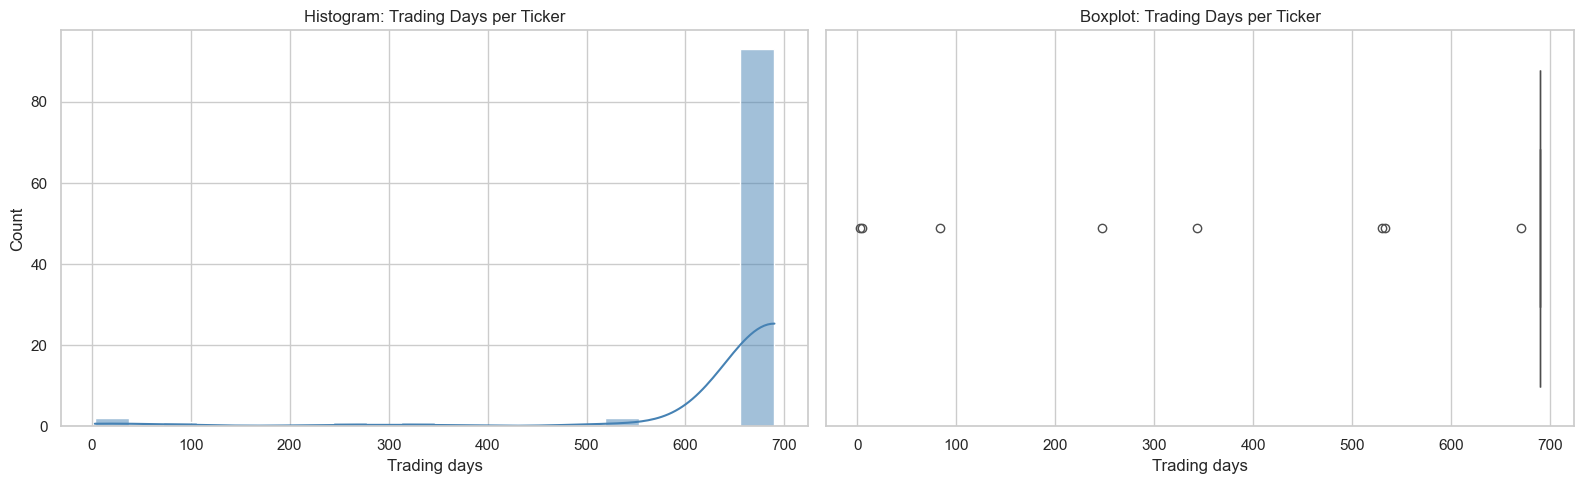


Tickers with low history (<250 days): 4


,Ticker,Trading_Days
0,HYUNDAI,247
1,ENRIN,83
2,TATACAP,5
3,TMPV,3


In [4]:
trading_days_per_ticker = df.groupby("Ticker")["Date"].count().sort_values(ascending=False)

coverage_stats = {
    "min": int(trading_days_per_ticker.min()),
    "max": int(trading_days_per_ticker.max()),
    "mean": float(trading_days_per_ticker.mean()),
    "median": float(trading_days_per_ticker.median()),
}

print("Trading days per ticker summary:")
for key, value in coverage_stats.items():
    print(f"  {key}: {value:.2f}" if isinstance(value, float) else f"  {key}: {value}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(trading_days_per_ticker, bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram: Trading Days per Ticker")
axes[0].set_xlabel("Trading days")

sns.boxplot(x=trading_days_per_ticker, ax=axes[1], color="orange")
axes[1].set_title("Boxplot: Trading Days per Ticker")
axes[1].set_xlabel("Trading days")
plt.tight_layout()
plt.show()

low_history_tickers = trading_days_per_ticker[trading_days_per_ticker < 250]
print(f"\nTickers with low history (<250 days): {len(low_history_tickers)}")
if len(low_history_tickers) > 0:
    display(low_history_tickers.reset_index(name="Trading_Days"))
else:
    print("None")

**Why minimum-history filtering is required before modeling:**

Tickers with short history provide unstable estimates of rolling indicators, volatility, and temporal patterns. They can bias model training toward noisy short windows and create uneven learning across symbols. Therefore, a minimum-history rule is necessary in preprocessing to ensure fair and statistically reliable modeling inputs.

## 5. Missing Value Analysis

This section quantifies missingness globally and by feature category, and visualizes missing patterns on a sample for readability.

In [5]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing_Count": missing_count, "Missing_%": missing_pct})
missing_summary = missing_summary[missing_summary["Missing_Count"] > 0]

print(f"Features with missing values: {missing_summary.shape[0]}")
display(missing_summary.head(20))

sample_size = min(4000, len(df))
sample_df = df.sample(sample_size, random_state=RANDOM_SEED).sort_values("Date")
cols_for_heatmap = missing_count[missing_count > 0].head(30).index.tolist()
if cols_for_heatmap:
    plt.figure(figsize=(16, 6))
    sns.heatmap(sample_df[cols_for_heatmap].isna(), cbar=False, yticklabels=False, cmap="viridis")
    plt.title("Missing Value Pattern (Sample)")
    plt.xlabel("Columns")
    plt.tight_layout()
    plt.show()

rows = []
for category, cols in column_groups.items():
    if not cols:
        continue
    category_missing = df[cols].isna().sum().sum()
    category_total = df[cols].shape[0] * df[cols].shape[1]
    rows.append({
        "Category": category,
        "Columns": len(cols),
        "Missing_Count": int(category_missing),
        "Missing_%": round((category_missing / category_total) * 100, 3),
    })

category_missing_summary = pd.DataFrame(rows).sort_values("Missing_%", ascending=False)
display(category_missing_summary)

Features with missing values: 0


,Missing_Count,Missing_%


,Category,Columns,Missing_Count,Missing_%
0,ID columns,2,0,0.0
1,Price columns,5,0,0.0
2,Return columns,3,0,0.0
3,Technical indicators,13,0,0.0
4,Global market features,7,0,0.0
5,GDELT features,7,0,0.0
6,Macro features,4,0,0.0


**Missing value context:** Rolling technical indicators (for example moving averages, ATR, rolling volatility) naturally produce initial NaNs because they require a lookback window. This is expected behavior in time-series feature construction and should be handled consistently during preprocessing.

## 6. Price and Return Analysis

We examine return distributions and visualize temporal price/return behavior for four representative tickers.

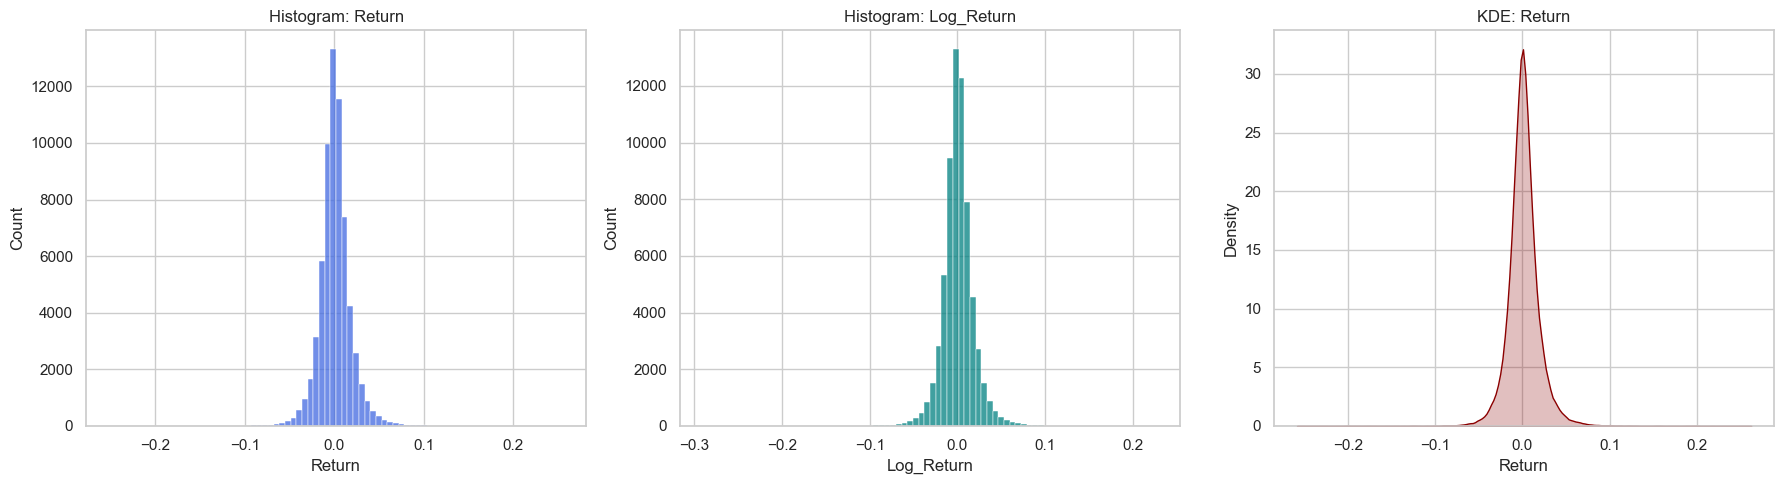

Representative tickers:
  Large-cap proxy (highest avg volume): ETERNAL
  Mid-cap proxy (near-median avg volume): ADANIENSOL
  Volatile proxy (highest return std): MAZDOCK
  Random: AXISBANK


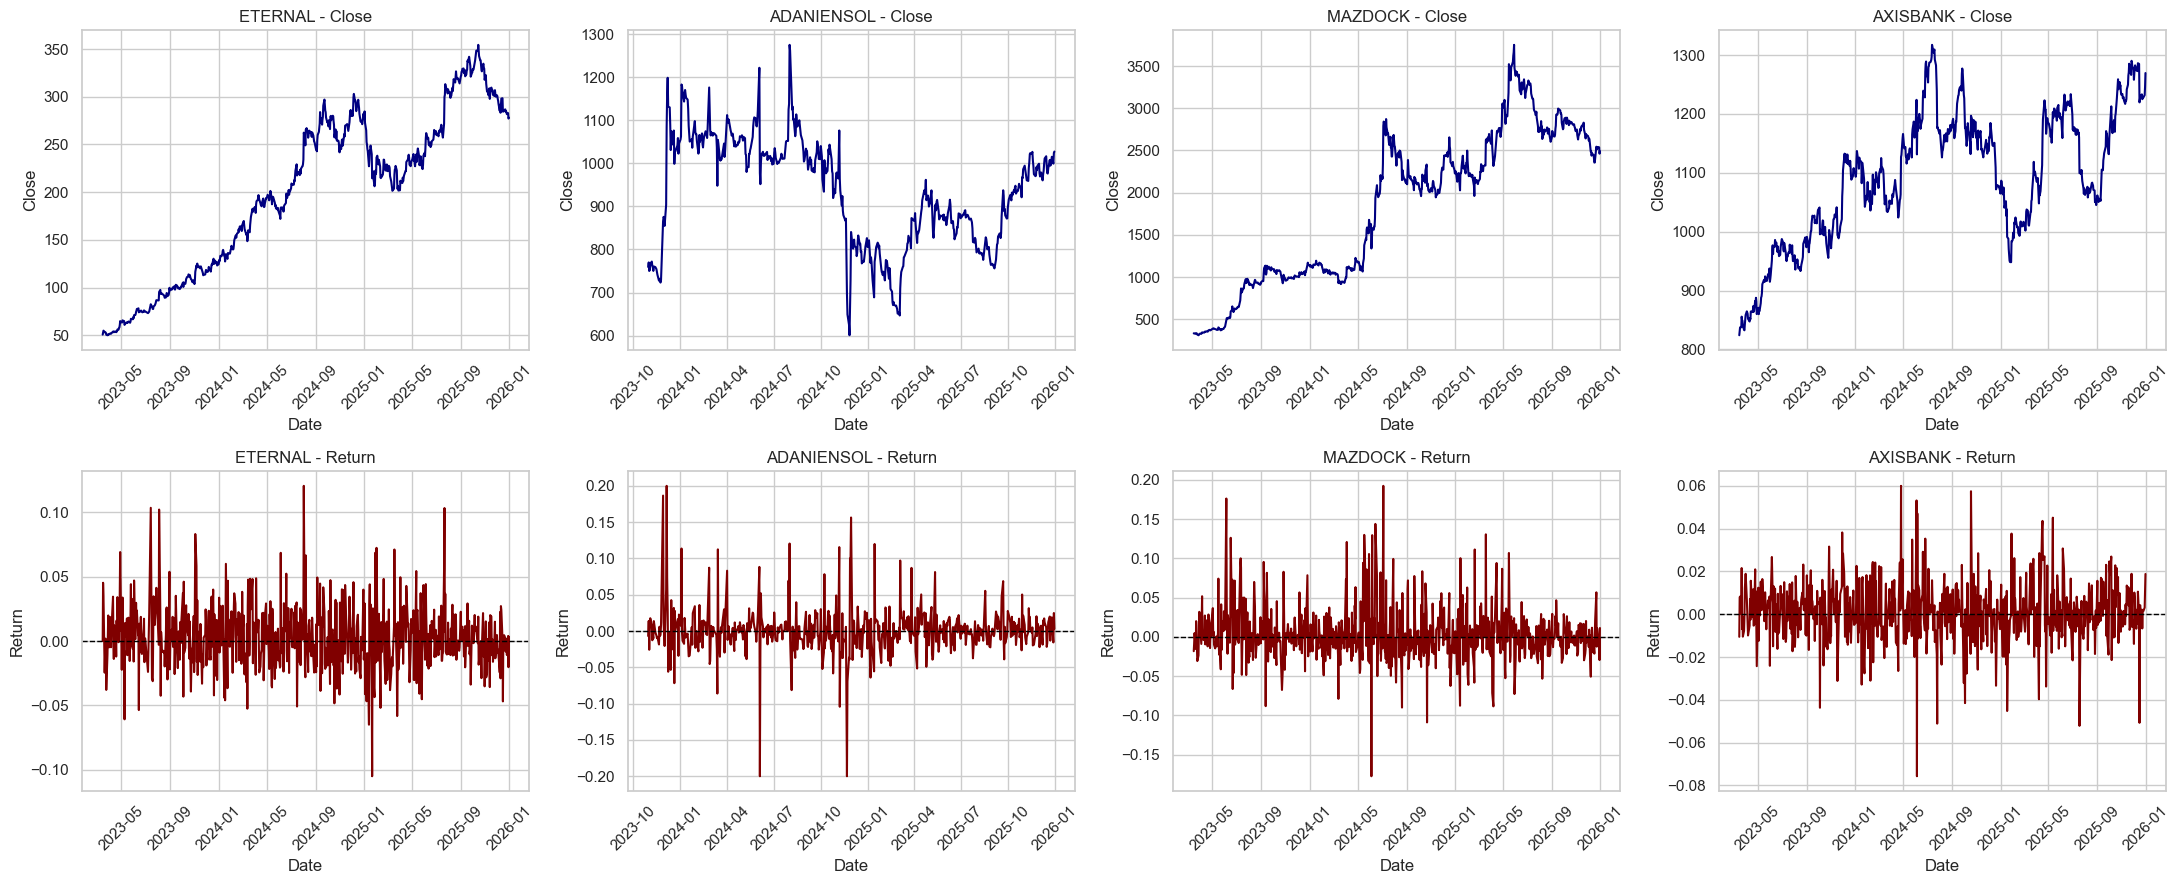

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if "Return" in df.columns:
    sns.histplot(df["Return"].dropna(), bins=80, ax=axes[0], color="royalblue")
    axes[0].set_title("Histogram: Return")
if "Log_Return" in df.columns:
    sns.histplot(df["Log_Return"].dropna(), bins=80, ax=axes[1], color="teal")
    axes[1].set_title("Histogram: Log_Return")
if "Return" in df.columns:
    sns.kdeplot(df["Return"].dropna(), fill=True, ax=axes[2], color="darkred")
    axes[2].set_title("KDE: Return")
plt.tight_layout()
plt.show()

ticker_stats = df.groupby("Ticker").agg(
    avg_volume=("Volume", "mean"),
    volatility=("Return", "std"),
).dropna()

large_cap_ticker = ticker_stats["avg_volume"].idxmax()
median_volume = ticker_stats["avg_volume"].median()
mid_cap_ticker = (ticker_stats.drop(index=large_cap_ticker)["avg_volume"] - median_volume).abs().idxmin()
volatile_ticker = ticker_stats["volatility"].idxmax()

rng = np.random.default_rng(RANDOM_SEED)
excluded = {large_cap_ticker, mid_cap_ticker, volatile_ticker}
candidate_random = [t for t in ticker_stats.index if t not in excluded]
random_ticker = rng.choice(candidate_random) if candidate_random else volatile_ticker

representative_tickers = [large_cap_ticker, mid_cap_ticker, volatile_ticker, random_ticker]
print("Representative tickers:")
print(f"  Large-cap proxy (highest avg volume): {large_cap_ticker}")
print(f"  Mid-cap proxy (near-median avg volume): {mid_cap_ticker}")
print(f"  Volatile proxy (highest return std): {volatile_ticker}")
print(f"  Random: {random_ticker}")

fig, axes = plt.subplots(2, len(representative_tickers), figsize=(22, 9), sharex=False)
for idx, ticker in enumerate(representative_tickers):
    sub = df[df["Ticker"] == ticker].sort_values("Date")
    sns.lineplot(data=sub, x="Date", y="Close", ax=axes[0, idx], color="navy")
    axes[0, idx].set_title(f"{ticker} - Close")
    axes[0, idx].tick_params(axis="x", rotation=45)

    sns.lineplot(data=sub, x="Date", y="Return", ax=axes[1, idx], color="maroon")
    axes[1, idx].axhline(0, linestyle="--", color="black", linewidth=1)
    axes[1, idx].set_title(f"{ticker} - Return")
    axes[1, idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Volatility Analysis

Ticker-level return volatility is computed and ranked to understand regime diversity before volatility clustering.

,Ticker,Volatility_STD
0,MAZDOCK,0.033984
1,ADANIENSOL,0.032228
2,PAYTM,0.031729
3,ADANIGREEN,0.031166
4,IRFC,0.030397
5,ADANIPOWER,0.029555
6,RECLTD,0.026186
7,ADANIENT,0.026043
8,LODHA,0.025720
9,PFC,0.025642


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_24304\556443584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, ax=axes[1], palette="Reds_r")
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_24304\556443584.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom10.values, y=bottom10.index, ax=axes[2], palette="Greens")


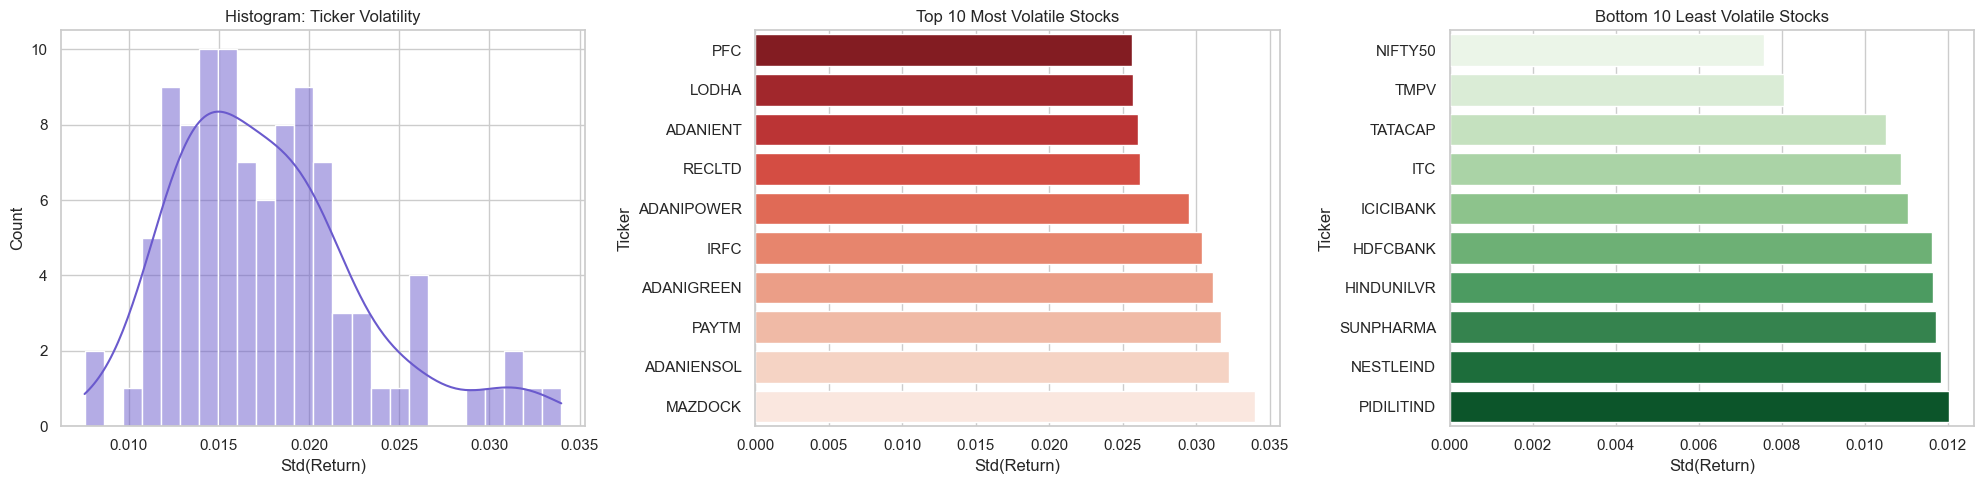

In [7]:
ticker_volatility = df.groupby("Ticker")["Return"].std().dropna().sort_values(ascending=False)

display(ticker_volatility.rename("Volatility_STD").reset_index().head(10))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.histplot(ticker_volatility, bins=25, kde=True, ax=axes[0], color="slateblue")
axes[0].set_title("Histogram: Ticker Volatility")
axes[0].set_xlabel("Std(Return)")

top10 = ticker_volatility.head(10).sort_values()
sns.barplot(x=top10.values, y=top10.index, ax=axes[1], palette="Reds_r")
axes[1].set_title("Top 10 Most Volatile Stocks")
axes[1].set_xlabel("Std(Return)")
axes[1].set_ylabel("Ticker")

bottom10 = ticker_volatility.tail(10).sort_values()
sns.barplot(x=bottom10.values, y=bottom10.index, ax=axes[2], palette="Greens")
axes[2].set_title("Bottom 10 Least Volatile Stocks")
axes[2].set_xlabel("Std(Return)")
axes[2].set_ylabel("Ticker")

plt.tight_layout()
plt.show()

**Why this matters for volatility clustering:**

Volatility variation across stocks is structurally meaningful and supports separating tickers into volatility regimes (volatile/stable/non-volatile). Regime-specific modeling can improve robustness by aligning model complexity and features with each group's noise level and return dynamics.

## 8. Technical Indicator Analysis

We inspect distributions and outlier behavior for key technical indicators used in downstream modeling.

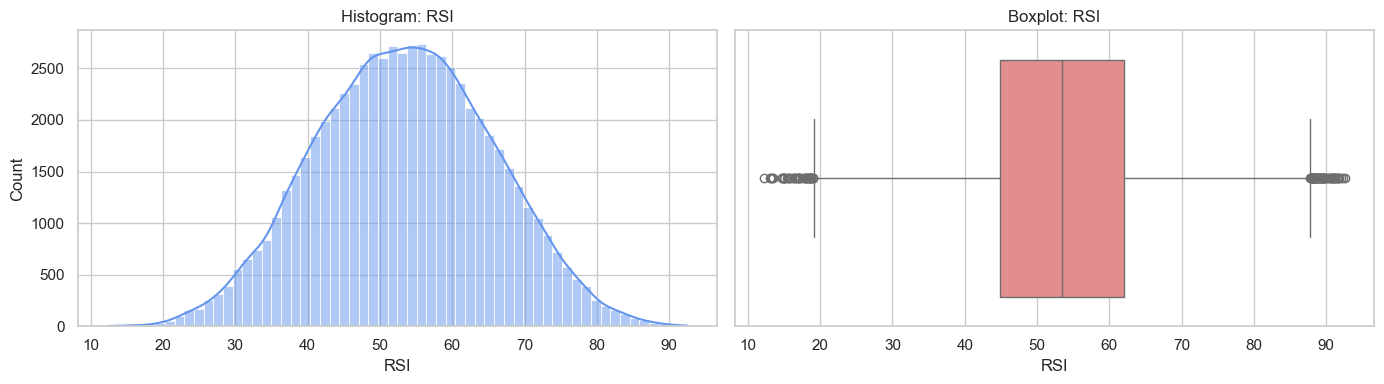

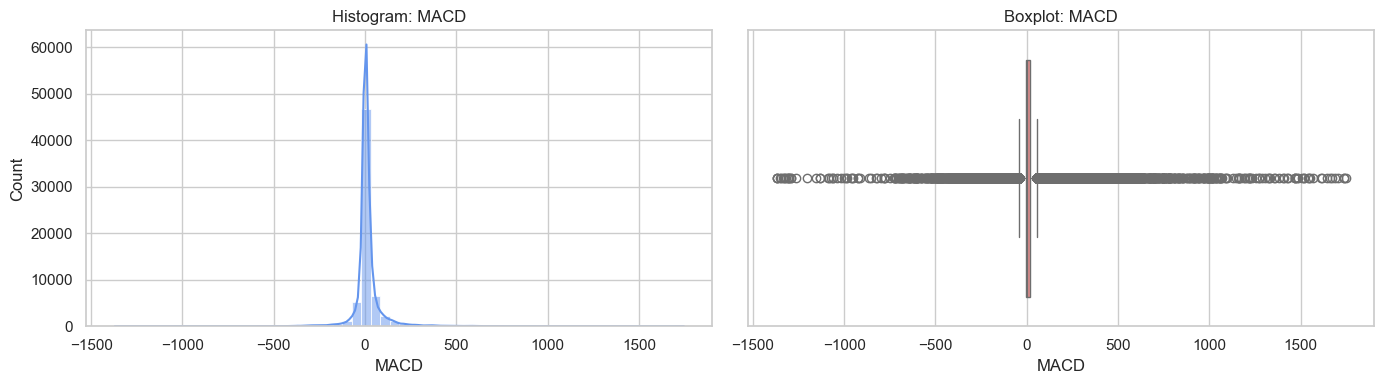

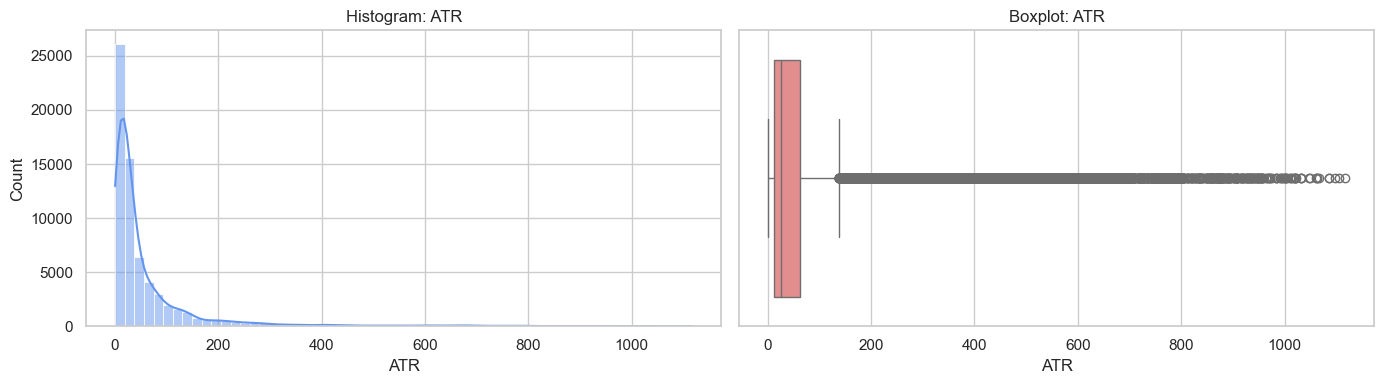

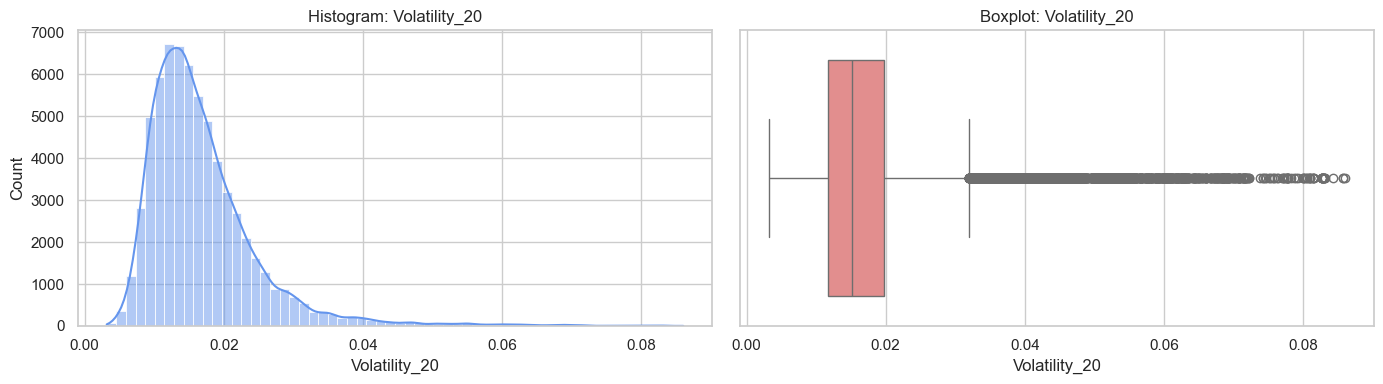

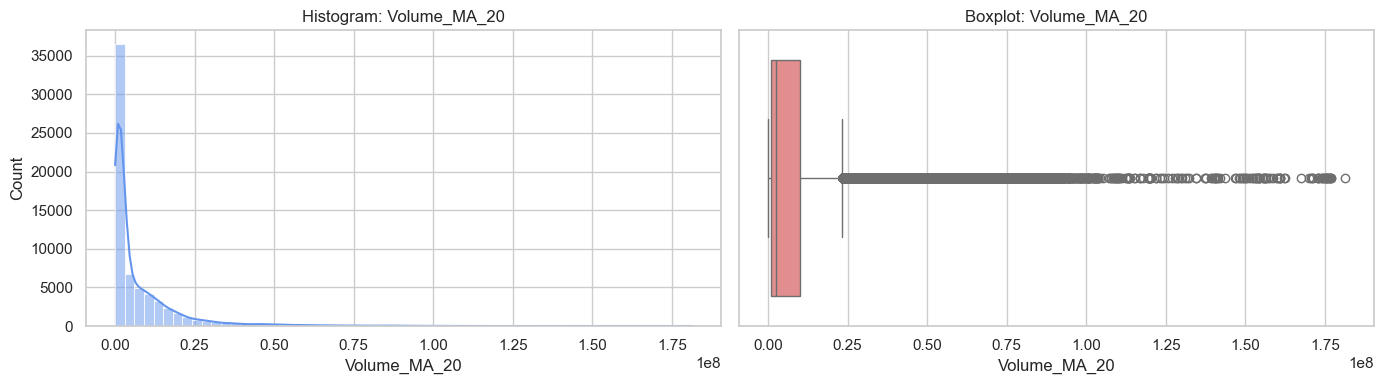

,Feature,Skewness,Std,Q1,Median,Q3
0,RSI,0.0081,1.217760e+01,44.8197,5.346400e+01,6.197780e+01
1,MACD,3.1198,9.816110e+01,-4.7035,3.206000e+00,1.970550e+01
2,ATR,4.3231,1.091453e+02,11.3330,2.611300e+01,6.228130e+01
3,Volatility_20,2.3898,8.000000e-03,0.0117,1.510000e-02,1.980000e-02
4,Volume_MA_20,4.3064,1.364291e+07,933959.2000,2.440376e+06,9.930272e+06


In [8]:
technical_focus = ["RSI", "MACD", "ATR", "Volatility_20", "Volume_MA_20"]
technical_focus = [c for c in technical_focus if c in df.columns]

for col in technical_focus:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[col].dropna(), bins=60, kde=True, ax=axes[0], color="cornflowerblue")
    axes[0].set_title(f"Histogram: {col}")
    sns.boxplot(x=df[col].dropna(), ax=axes[1], color="lightcoral")
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

tech_distribution = pd.DataFrame({
    "Feature": technical_focus,
    "Skewness": [df[c].dropna().skew() for c in technical_focus],
    "Std": [df[c].dropna().std() for c in technical_focus],
    "Q1": [df[c].dropna().quantile(0.25) for c in technical_focus],
    "Median": [df[c].dropna().median() for c in technical_focus],
    "Q3": [df[c].dropna().quantile(0.75) for c in technical_focus],
}).round(4)
display(tech_distribution)

## 9. Global Market Analysis

We examine how Indian market returns relate to major global risk and commodity proxies.

,Pair,Correlation
0,NIFTY_RET vs SP500_RET,0.1402
1,NIFTY_RET vs VIX_RET,-0.1487
2,NIFTY_RET vs OIL_RET,-0.0154
3,NIFTY_RET vs USDINR_RET,-0.0258


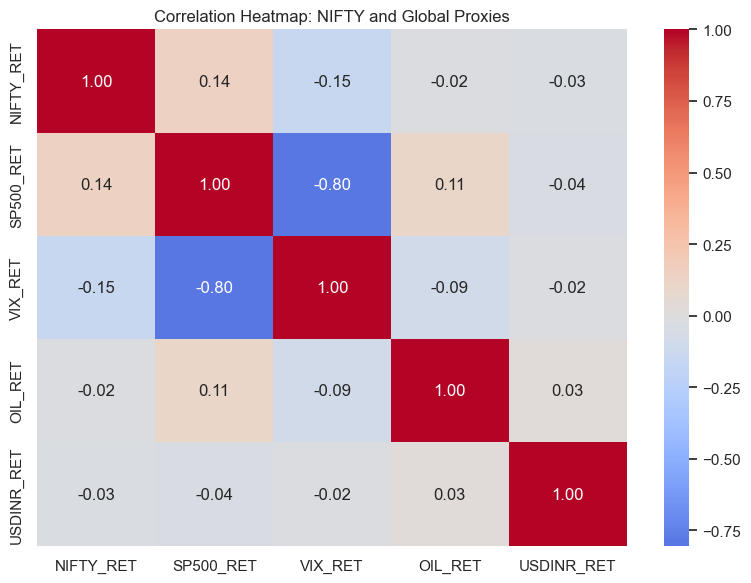

In [9]:
global_pairs = ["SP500_RET", "VIX_RET", "OIL_RET", "USDINR_RET"]
global_pairs = [c for c in global_pairs if c in df.columns and "NIFTY_RET" in df.columns]

global_corr_rows = []
for col in global_pairs:
    corr_val = df[["NIFTY_RET", col]].dropna().corr().iloc[0, 1]
    global_corr_rows.append({"Pair": f"NIFTY_RET vs {col}", "Correlation": corr_val})

global_corr_df = pd.DataFrame(global_corr_rows)
display(global_corr_df.round(4))

heatmap_cols = ["NIFTY_RET"] + global_pairs
if len(heatmap_cols) > 1:
    corr_mat = df[heatmap_cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap: NIFTY and Global Proxies")
    plt.tight_layout()
    plt.show()

Global proxies capture external risk transmission channels (risk-on/risk-off sentiment, commodity shocks, and FX movement). Their lagged association with NIFTY returns helps guide interaction features and macro-regime-aware modeling.

## 10. GDELT Event Analysis

This section studies event intensity, tone, and thematic event flags over time.

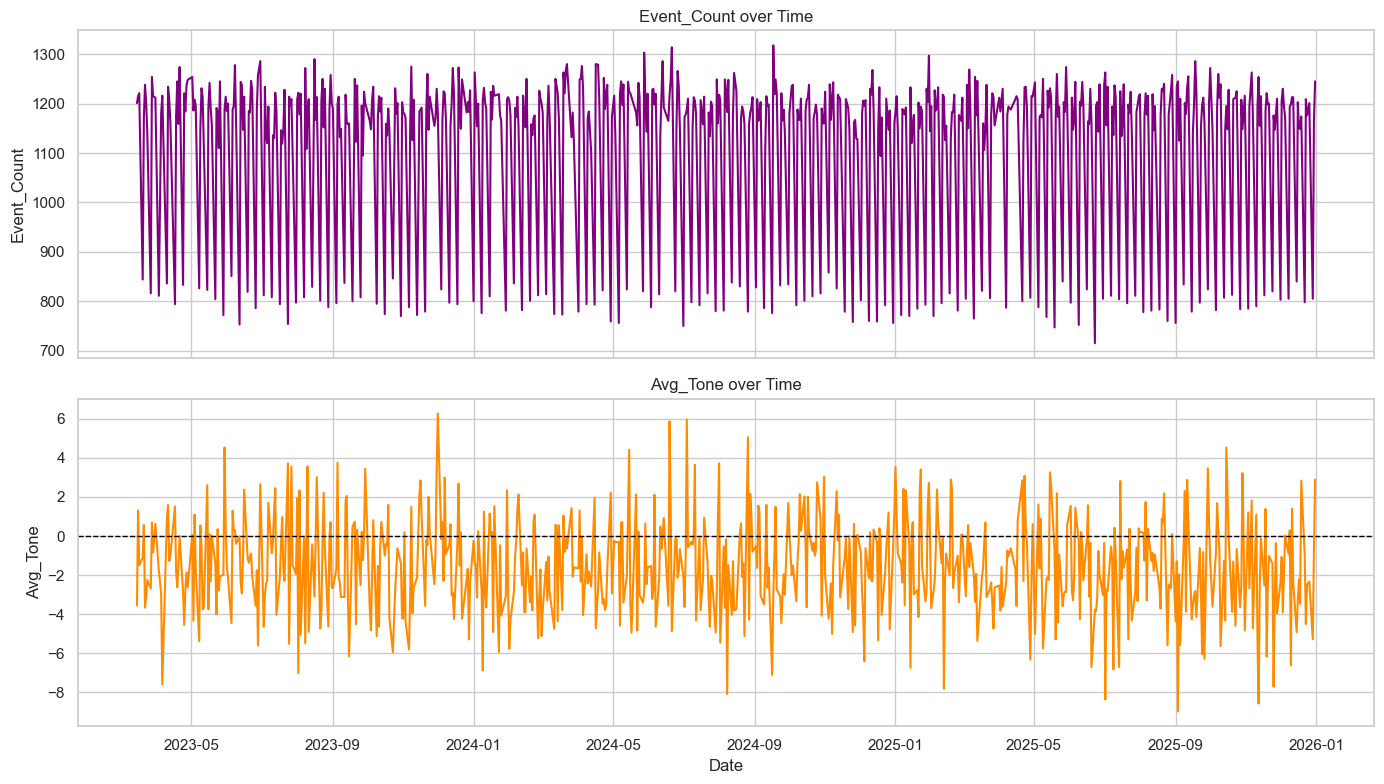

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_24304\4175089735.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flag_freq.index, y=flag_freq.values, palette="magma")


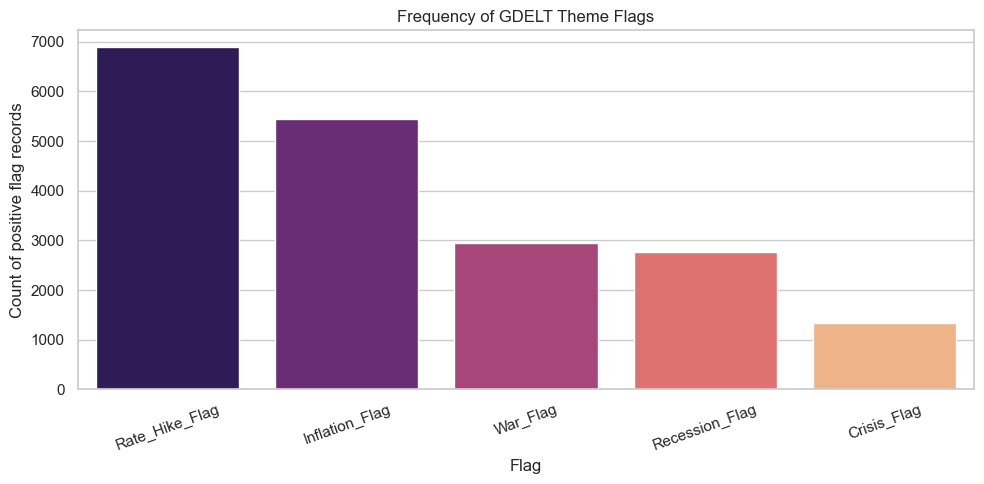

,Flag,Frequency
0,Rate_Hike_Flag,6884
1,Inflation_Flag,5449
2,War_Flag,2951
3,Recession_Flag,2764
4,Crisis_Flag,1344


In [11]:
daily_gdelt = df.groupby("Date").agg(
    Event_Count=("Event_Count", "mean"),
    Avg_Tone=("Avg_Tone", "mean"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=daily_gdelt, x="Date", y="Event_Count", ax=axes[0], color="purple")
axes[0].set_title("Event_Count over Time")

sns.lineplot(data=daily_gdelt, x="Date", y="Avg_Tone", ax=axes[1], color="darkorange")
axes[1].set_title("Avg_Tone over Time")
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
plt.tight_layout()
plt.show()

flag_cols = ["War_Flag", "Crisis_Flag", "Inflation_Flag", "Rate_Hike_Flag", "Recession_Flag"]
flag_cols = [c for c in flag_cols if c in df.columns]
flag_freq = df[flag_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=flag_freq.index, y=flag_freq.values, palette="magma")
plt.title("Frequency of GDELT Theme Flags")
plt.xlabel("Flag")
plt.ylabel("Count of positive flag records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(flag_freq.rename("Frequency").reset_index().rename(columns={"index": "Flag"}))

## 11. Macro Economic Analysis

We inspect macroeconomic trends over time to contextualize market behavior and potential regime shifts.

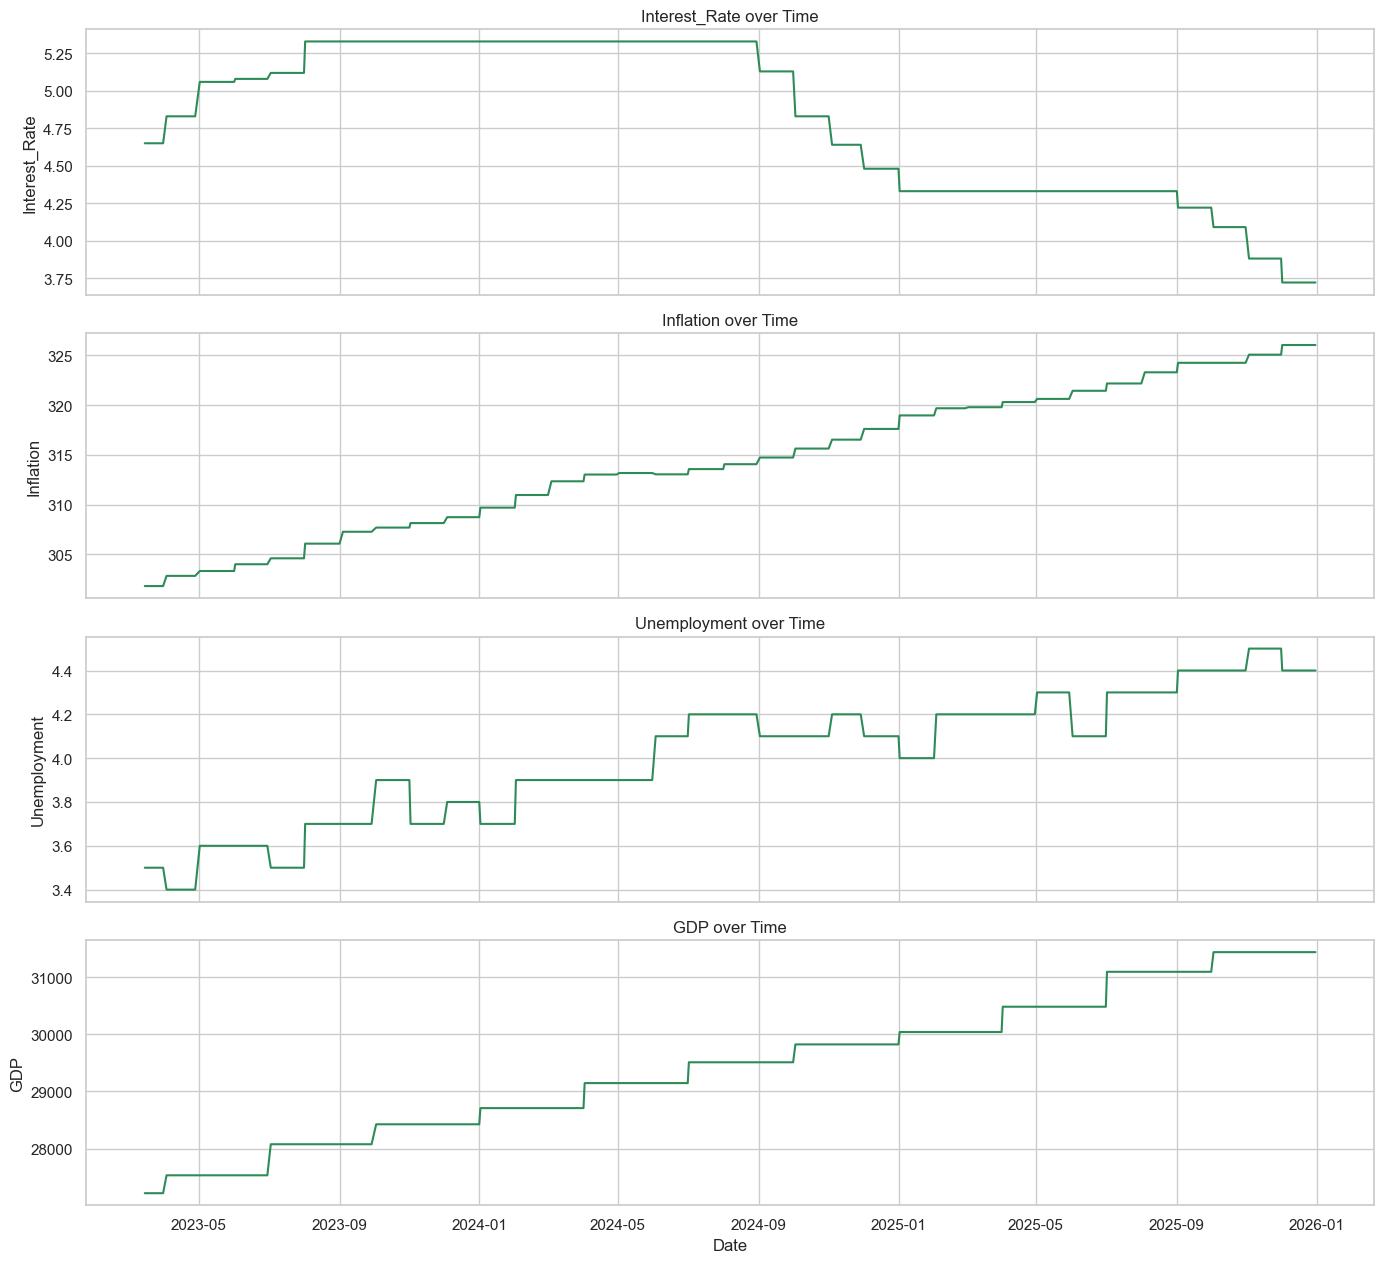

,count,mean,std,min,25%,50%,75%,max
Interest_Rate,690.0,4.8140,0.5114,3.720,4.330,5.060,5.330,5.330
Inflation,690.0,314.4465,6.9778,301.821,308.148,314.062,320.302,326.031
Unemployment,690.0,4.0077,0.2880,3.400,3.700,4.100,4.200,4.500
GDP,690.0,29450.3619,1213.7093,27216.445,28424.722,29511.664,30485.729,31442.483


In [12]:
macro_cols = ["Interest_Rate", "Inflation", "Unemployment", "GDP"]
macro_cols = [c for c in macro_cols if c in df.columns]
macro_daily = df.groupby("Date")[macro_cols].mean().reset_index()

fig, axes = plt.subplots(len(macro_cols), 1, figsize=(14, 3.2 * len(macro_cols)), sharex=True)
if len(macro_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, macro_cols):
    sns.lineplot(data=macro_daily, x="Date", y=col, ax=ax, color="seagreen")
    ax.set_title(f"{col} over Time")

plt.tight_layout()
plt.show()

display(macro_daily[macro_cols].describe().T.round(4))

Macro series can encode broader economic regimes (policy tightening/loosening, growth and labor shifts). These variables are useful as slow-moving contextual features for risk and trend prediction.

## 12. Correlation Analysis

We compute a focused cross-domain correlation matrix and identify strongly correlated and potentially redundant features.

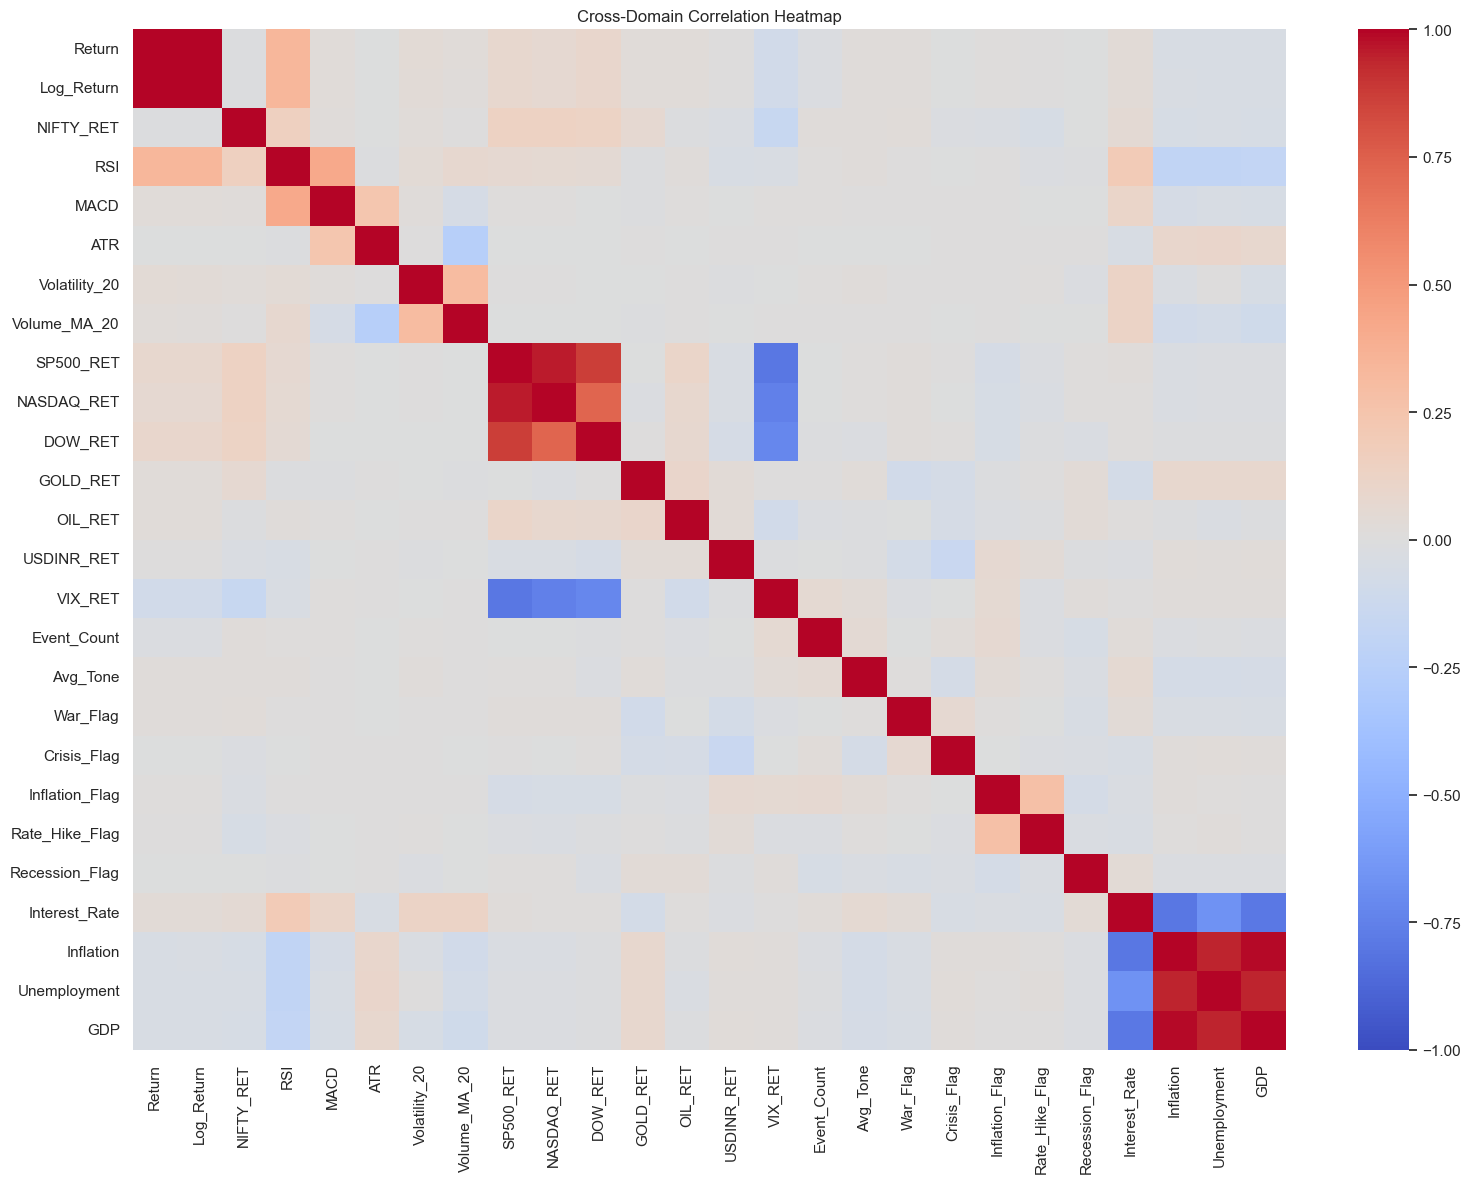

Strong correlations (|corr| >= 0.70):


,Feature_1,Feature_2,Correlation
0,Return,Log_Return,0.999348
323,Inflation,GDP,0.989986
172,SP500_RET,NASDAQ_RET,0.954904
324,Unemployment,GDP,0.943831
322,Inflation,Unemployment,0.940968
173,SP500_RET,DOW_RET,0.874853
177,SP500_RET,VIX_RET,-0.803405
319,Interest_Rate,Inflation,-0.799912
321,Interest_Rate,GDP,-0.792678
193,NASDAQ_RET,VIX_RET,-0.754431


Potentially redundant feature set (review with domain logic):
['Return', 'Inflation', 'SP500_RET', 'Unemployment', 'Interest_Rate', 'NASDAQ_RET', 'DOW_RET', 'Log_Return', 'GDP', 'VIX_RET']


In [13]:
corr_feature_pool = [
    "Return", "Log_Return", "NIFTY_RET",
    "RSI", "MACD", "ATR", "Volatility_20", "Volume_MA_20",
    "SP500_RET", "NASDAQ_RET", "DOW_RET", "GOLD_RET", "OIL_RET", "USDINR_RET", "VIX_RET",
    "Event_Count", "Avg_Tone", "War_Flag", "Crisis_Flag", "Inflation_Flag", "Rate_Hike_Flag", "Recession_Flag",
    "Interest_Rate", "Inflation", "Unemployment", "GDP",
]
corr_cols = [c for c in corr_feature_pool if c in df.columns]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Cross-Domain Correlation Heatmap")
plt.tight_layout()
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)
strong_corr = strong_corr[strong_corr["Correlation"].abs() >= 0.70].sort_values("Correlation", key=np.abs, ascending=False)

print("Strong correlations (|corr| >= 0.70):")
display(strong_corr.head(20))

redundant_features = pd.unique(strong_corr[["Feature_1", "Feature_2"]].values.ravel("K")).tolist() if not strong_corr.empty else []
print("Potentially redundant feature set (review with domain logic):")
print(redundant_features if redundant_features else "No highly correlated pairs above threshold.")

## 13. Outlier Analysis

We inspect outlier-prone financial features to understand heavy tails and extreme market conditions.

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_24304\1291709597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="Feature", y="Value", palette="Set2")


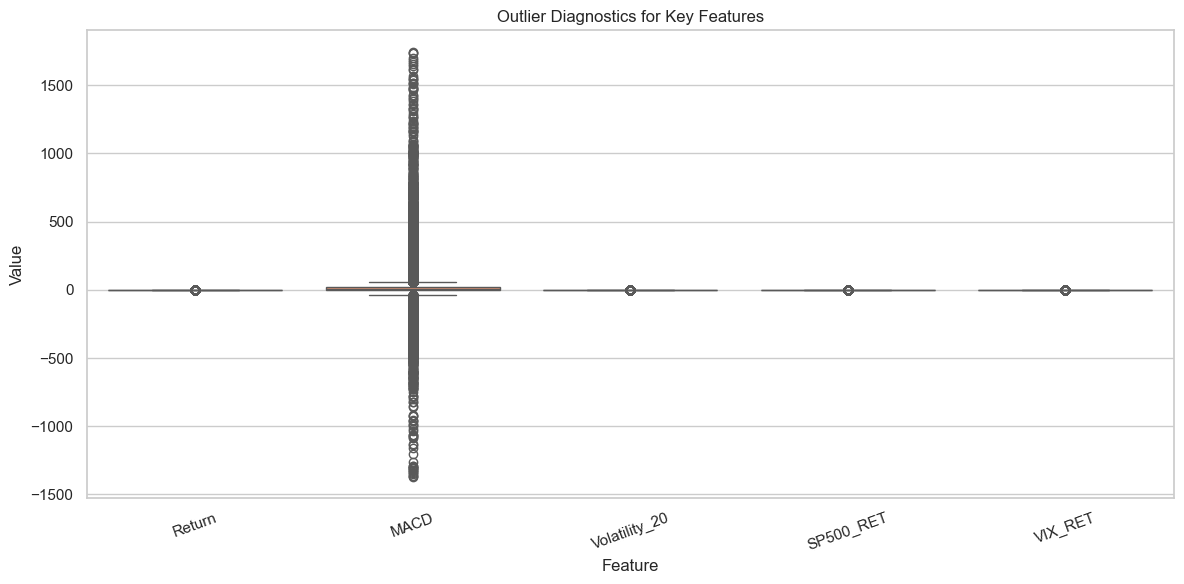

In [14]:
outlier_cols = ["Return", "MACD", "Volatility_20", "SP500_RET", "VIX_RET"]
outlier_cols = [c for c in outlier_cols if c in df.columns]

melted = df[outlier_cols].melt(var_name="Feature", value_name="Value").dropna()

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="Feature", y="Value", palette="Set2")
plt.title("Outlier Diagnostics for Key Features")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Financial data naturally contains outliers due to event shocks, liquidity changes, and regime transitions. Outliers should be handled carefully (robust scaling/winsorization/feature transformation) without removing informative tail behavior.

## 14. Final Insights

The following summary consolidates key EDA findings for feature engineering and modeling design.

In [15]:
overall_missing_pct = (df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100

vol_q = ticker_volatility.quantile([0.33, 0.67]).to_dict()
vol_min, vol_max = ticker_volatility.min(), ticker_volatility.max()

avg_event_count = float(df["Event_Count"].mean()) if "Event_Count" in df.columns else np.nan
avg_tone = float(df["Avg_Tone"].mean()) if "Avg_Tone" in df.columns else np.nan

macro_snapshot = {}
for col in ["Interest_Rate", "Inflation", "Unemployment", "GDP"]:
    if col in macro_daily.columns:
        macro_snapshot[col] = (float(macro_daily[col].iloc[0]), float(macro_daily[col].iloc[-1]))

def iqr_outlier_pct(series: pd.Series) -> float:
    s = series.dropna()
    if s.empty:
        return np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < low) | (s > high)).mean() * 100

outlier_return_pct = iqr_outlier_pct(df["Return"]) if "Return" in df.columns else np.nan

global_text = ""
if not global_corr_df.empty:
    lines = [f"- {row.Pair}: {row.Correlation:.3f}" for row in global_corr_df.itertuples(index=False)]
    global_text = "\n".join(lines)

low_history_list = ", ".join(low_history_tickers.index.tolist()) if len(low_history_tickers) > 0 else "None"

insight_md = f"""
### EDA Summary

- **Dataset quality:** {df.shape[0]:,} rows, {df.shape[1]} features, {unique_tickers} tickers, date range **{date_min.date()} to {date_max.date()}**. Overall missingness is **{overall_missing_pct:.2f}%** and is primarily expected in rolling-window features.
- **Feature distributions:** Return-based features show non-normality and fat tails; technical indicators present feature-specific skew and outlier spread requiring robust preprocessing choices.
- **Volatility differences across stocks:** Ticker volatility spans **{vol_min:.4f} to {vol_max:.4f}** (std of returns), with regime cut references near 33rd/67th percentiles at **{vol_q.get(0.33, np.nan):.4f}** and **{vol_q.get(0.67, np.nan):.4f}**.
- **Influence of global markets:**
{global_text if global_text else '- Correlation pairs unavailable due to missing columns.'}
- **Impact of global events (GDELT):** Mean event intensity is **{avg_event_count:.2f}**, mean tone is **{avg_tone:.3f}**; event-theme flags provide structured geopolitical/economic shock context.
- **Macroeconomic trends:** Macro variables evolve gradually over time, supporting their use as slow-moving regime/context signals rather than high-frequency predictors.
- **Outlier observations:** Approximate IQR-based outlier share in `Return` is **{outlier_return_pct:.2f}%**, consistent with shock-driven financial tails.
- **Data coverage issues:** Trading-day coverage varies across tickers (min/median/max = **{coverage_stats['min']} / {coverage_stats['median']:.0f} / {coverage_stats['max']}**). Low-history tickers (<250 days): **{len(low_history_tickers)}**.
- **Justification for minimum-history filtering:** Sufficient history is necessary for stable rolling features, volatility estimation, and fair cross-ticker model learning; filtering should be applied in preprocessing (not in this EDA step).
- **Feature engineering strategy forward:** Prioritize leakage-safe lag design, robust scaling for heavy-tailed variables, interaction terms between local and global signals, event/macro temporal smoothing, and multicollinearity-aware selection.
"""

display(Markdown(insight_md))

if len(low_history_tickers) > 0:
    print("Low-history ticker list (<250 days):")
    print(low_history_list)


### EDA Summary

- **Dataset quality:** 65,895 rows, 41 features, 100 tickers, date range **2023-03-15 to 2025-12-31**. Overall missingness is **0.00%** and is primarily expected in rolling-window features.
- **Feature distributions:** Return-based features show non-normality and fat tails; technical indicators present feature-specific skew and outlier spread requiring robust preprocessing choices.
- **Volatility differences across stocks:** Ticker volatility spans **0.0076 to 0.0340** (std of returns), with regime cut references near 33rd/67th percentiles at **0.0146** and **0.0192**.
- **Influence of global markets:**
- NIFTY_RET vs SP500_RET: 0.140
- NIFTY_RET vs VIX_RET: -0.149
- NIFTY_RET vs OIL_RET: -0.015
- NIFTY_RET vs USDINR_RET: -0.026
- **Impact of global events (GDELT):** Mean event intensity is **1119.41**, mean tone is **-1.492**; event-theme flags provide structured geopolitical/economic shock context.
- **Macroeconomic trends:** Macro variables evolve gradually over time, supporting their use as slow-moving regime/context signals rather than high-frequency predictors.
- **Outlier observations:** Approximate IQR-based outlier share in `Return` is **5.49%**, consistent with shock-driven financial tails.
- **Data coverage issues:** Trading-day coverage varies across tickers (min/median/max = **3 / 690 / 690**). Low-history tickers (<250 days): **4**.
- **Justification for minimum-history filtering:** Sufficient history is necessary for stable rolling features, volatility estimation, and fair cross-ticker model learning; filtering should be applied in preprocessing (not in this EDA step).
- **Feature engineering strategy forward:** Prioritize leakage-safe lag design, robust scaling for heavy-tailed variables, interaction terms between local and global signals, event/macro temporal smoothing, and multicollinearity-aware selection.


Low-history ticker list (<250 days):
HYUNDAI, ENRIN, TATACAP, TMPV
